In [28]:
# 1. Imports

# Import pandas for data handling
import pandas as pd

# Import numpy for numerical operations
import numpy as np

# Import matplotlib for plotting
import matplotlib.pyplot as plt

# Import matplotlib for plot customization
import matplotlib as m

# Import seaborn for statistical visualization
import seaborn as sns

# Import statsmodels for statistical modeling
import statsmodels.api as sm

# Import seasonal_decompose for time-series analysis
from statsmodels.tsa.seasonal import seasonal_decompose

In [29]:
#testing things

In [30]:
   %pip install pandas numpy matplotlib seaborn statsmodels scipy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [31]:
# 2. Formatting Graph Outputs

# Set Matplotlib to default style for a minimalist look
plt.style.use('default')

# Allow all columns to display without truncation
pd.set_option('display.max_columns', 500)

# Auto-adjust pandas display width for readability
pd.set_option('display.width', None)

# Set default figure size for visible graphs
m.rcParams['figure.figsize'] = (12, 6)

# Set font size for axis labels and tick labels
m.rcParams['axes.labelsize'] = 12
m.rcParams['xtick.labelsize'] = 10
m.rcParams['ytick.labelsize'] = 10

# Make axis titles bold for emphasis
m.rcParams['axes.titleweight'] = 'bold'

# Ensure text color is black for readability
m.rcParams['text.color'] = 'black'

# Increase line width for better visibility
m.rcParams['lines.linewidth'] = 2

# Set axis lines: thin, light gray for subtlety
m.rcParams['axes.axisbelow'] = True
m.rcParams['axes.grid'] = False
m.rcParams['axes.linewidth'] = 0.8
m.rcParams['axes.edgecolor'] = 'gray'

# Add custom grid: light gray, dotted, thin lines
m.rcParams['grid.color'] = 'gray'
m.rcParams['grid.linestyle'] = ':'
m.rcParams['grid.linewidth'] = 0.8
m.rcParams['grid.alpha'] = 0.5

In [32]:
# 3. Loading the Data
df = pd.read_csv('Electric_Production.csv', skiprows=1, header = None)
#Here we skip the 1st line because it would have showed us the headers of the csv file

# 4. Visualizing the Data
df.head()

,0,1
0,1939-01-01,3.3336
1,1939-02-01,3.3591
2,1939-03-01,3.4354
3,1939-04-01,3.4608
4,1939-05-01,3.4608


In [33]:
df.columns = ['Month','Energy_Consumption']
df.head()

,Month,Energy_Consumption
0,1939-01-01,3.3336
1,1939-02-01,3.3591
2,1939-03-01,3.4354
3,1939-04-01,3.4608
4,1939-05-01,3.4608


In [34]:
df.describe()

,Energy_Consumption
count,1051.000000
mean,57.884278
std,36.430104
min,3.333600
25%,21.350350
50%,58.278000
75%,90.777050
max,132.843100


In [35]:
#Month with the last consumption
df.max()

Month                 2026-07-01
Energy_Consumption      132.8431
dtype: object

In [36]:
#Full period of the time series  
print('Start of Time Period: {}'  ' End of Time Period: {}'.format(  
    df.Month.min(), df.Month.max()  
))


Start of Time Period: 1939-01-01 End of Time Period: 2026-07-01


In [37]:
df.shape


(1051, 2)

In [38]:
type(df)

pandas.DataFrame

In [39]:
# DATA VISUALIZATION 
df.head


<bound method NDFrame.head of            Month  Energy_Consumption
0     1939-01-01              3.3336
1     1939-02-01              3.3591
2     1939-03-01              3.4354
3     1939-04-01              3.4608
4     1939-05-01              3.4608
...          ...                 ...
1046  2026-03-01            102.8271
1047  2026-04-01             94.5139
1048  2026-05-01             97.7154
1049  2026-06-01            110.8105
1050  2026-07-01            124.3069

[1051 rows x 2 columns]>

In [40]:
df.dtypes


Month                     str
Energy_Consumption    float64
dtype: object

In [41]:
df['Month'] = pd.to_datetime(df['Month'], format='%Y-%m')
df.head()

ValueError: unconverted data remains when parsing with format "%Y-%m": "-01". You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [ ]:

#Month as index
df_series = df.set_index('Month')
df_series.head()

,Energy_Consumption
Month,
1939-01-01,3.3336
1939-02-01,3.3591
1939-03-01,3.4354
1939-04-01,3.4608
1939-05-01,3.4608


In [ ]:
df_series.index

DatetimeIndex(['1939-01-01', '1939-02-01', '1939-03-01', '1939-04-01',
               '1939-05-01', '1939-06-01', '1939-07-01', '1939-08-01',
               '1939-09-01', '1939-10-01',
               ...
               '2025-10-01', '2025-11-01', '2025-12-01', '2026-01-01',
               '2026-02-01', '2026-03-01', '2026-04-01', '2026-05-01',
               '2026-06-01', '2026-07-01'],
              dtype='datetime64[us]', name='Month', length=1051, freq=None)

In [ ]:
#Missing data in the time series ? 
df_series.isnull().sum()

Energy_Consumption    0
dtype: int64

In [ ]:
# NICE, if they were we would have used interpolation or polynomiale equivalent IF we hadn't EXACT values for our dataset

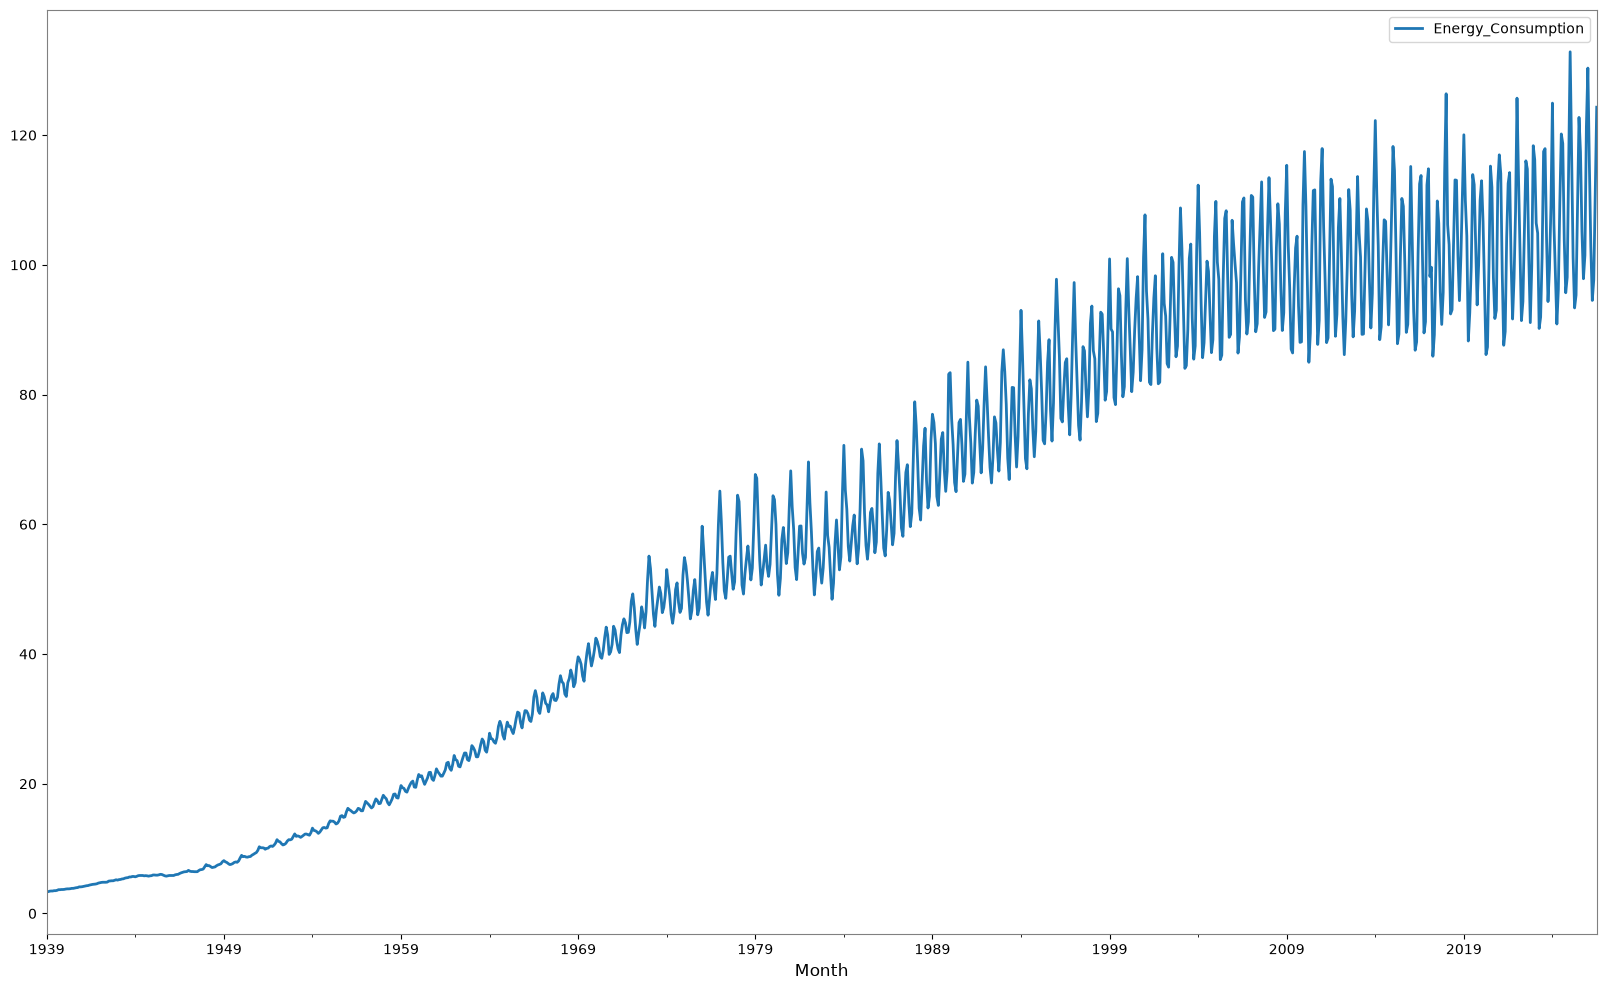

In [ ]:
#TIME SERIES TREND ANALYSIS

#Plot the time series
df_series.plot(figsize=(20,12))
plt.show()

In [ ]:
# We observe seasonality and a trend : both are easy to expect since its power consumption
# We can 

In [43]:
pd.crosstab(
    index=df_series["Month"], columns=df_series["Energy_Consumption"]
)

KeyError: 'Month'